<a href="https://colab.research.google.com/github/uiinlee/colab/blob/main/EEG_signal_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip -q install mne

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import mne
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

EDF_PATH = "/content/drive/MyDrive/Natus/2606221711_PDR_DIW/lee~ uiin_9b2ac926-e66b-4f34-b7ee-3c4623b549ec.edf"

edf_path = pathlib.Path(EDF_PATH)
assert edf_path.exists(), edf_path

raw = mne.io.read_raw_edf(edf_path, preload=False, infer_types=True, verbose=True)

print(raw)
print(raw.info)
print("Channels:", raw.ch_names)
print("Sampling freq:", raw.info["sfreq"])
print("Duration sec:", raw.n_times / raw.info["sfreq"])

Extracting EDF parameters from /content/drive/MyDrive/Natus/2606221711_PDR_DIW/lee~ uiin_9b2ac926-e66b-4f34-b7ee-3c4623b549ec.edf...
Setting channel info structure...
Creating raw.info structure...
<RawEDF | lee~ uiin_9b2ac926-e66b-4f34-b7ee-3c4623b549ec.edf, 34 x 391200 (1956.0 s), ~30 KiB, data not loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T3, A1, T5, O1, F3, C3, P3, Fpz, Fz, Cz, Pz, Fp2, F8, ...
 chs: 34 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: 2026-06-22 17:11:36 UTC
 nchan: 34
 projs: []
 sfreq: 200.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: lee,uiin>
>
Channels: ['Fp1', 'F7', 'T3', 'A1', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fpz', 'Fz', 'Cz', 'Pz', 'Fp2', 'F8', 'T4', 'A2', 'T6', 'O2', 'F4', 'C4', 'P4', 'X1', 'X2', 'DIF1', 'DIF2', 'DIF3', 'DIF4', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']
Sampling freq: 200.0
Duration sec: 1956.0


Reading 0 ... 4000  =      0.000 ...    20.000 secs...


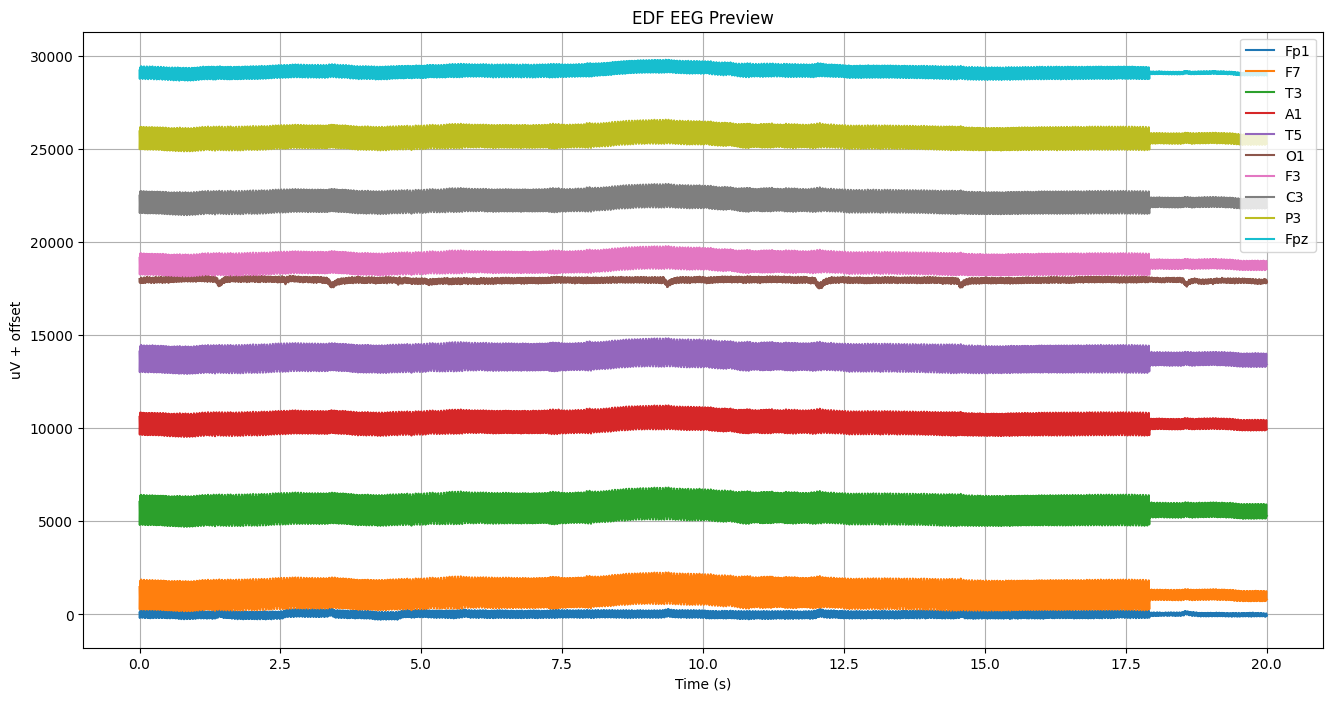

In [15]:
raw_preview = raw.copy().crop(tmin=0, tmax=min(20, raw.times[-1])).load_data()

picks = mne.pick_types(
    raw_preview.info,
    eeg=True,
    eog=True,
    ecg=True,
    emg=True,
    misc=True,
    exclude=[]
)

data, times = raw_preview[picks[:min(10, len(picks))]]

plt.figure(figsize=(16, 8))
offset = 0

for i, ch_data in enumerate(data):
    y = ch_data * 1e6
    y = y - np.nanmean(y)
    scale = np.nanstd(y)
    if not np.isfinite(scale) or scale == 0:
        scale = 100
    plt.plot(times, y + offset, label=raw_preview.ch_names[picks[i]])
    offset += scale * 8

plt.xlabel("Time (s)")
plt.ylabel("uV + offset")
plt.title("EDF EEG Preview")
plt.legend(loc="upper right")
plt.show()

In [21]:
!pip install wonambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.1/346.1 kB 6.7 MB/s eta 0:00:00


In [23]:
!pip install ioeeg

ERROR: Could not find a version that satisfies the requirement ioeeg (from versions: none)
ERROR: No matching distribution found for ioeeg


In [34]:
"""
Colab-ready KTLX/Natus ERD PDR/SNR analysis pipeline.

In Colab, run first:

    from google.colab import drive
    drive.mount('/content/drive')
    !pip -q install wonambi scipy pandas matplotlib

Then either paste this file into a Colab cell, or save it and run:

    %run colab_pdr_snr_erd_pipeline.py

This version reads .erd files directly. Keep the companion .etc/.stc/.ent files
in the same Google Drive folders.

Metrics:

1. PDR-vs-background spectral contrast, EC only:
   10*log10(mean PSD 8-13 Hz / mean PSD 1-40 Hz excluding 8-13 Hz)

2. EC/EO alpha physiological contrast:
   10*log10(mean alpha power during eyes-closed / mean alpha power during eyes-open)

3. RMS-based SNR:
   20*log10(mean RMS of EC 8-13 Hz signal / mean RMS of EO 1-40 Hz baseline)

Fill in eyes-open/baseline intervals for each recording before using metrics 2
and 3. If eo_intervals is empty, those two metrics will be NaN.
"""

from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path
import glob
import math
import re
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, welch
from scipy.stats import spearmanr
from wonambi.ioeeg import ktlx


# -----------------------------
# User configuration
# -----------------------------

BASE_DIR = Path("/content/drive/MyDrive/Natus")
OUT_DIR = Path("/content/drive/MyDrive/Natus/pdr_snr_erd_outputs")

CHANNELS = [
    "Fp1-O1",
    "Fp2-O2",
    "F3-O1",
    "F4-O2",
]

FS_EXPECTED = 200.0
SPECTRAL_RANGE = (1.0, 40.0)
PDR_BAND = (8.0, 13.0)
ALPHA_BAND_FOR_EC_EO = (8.0, 13.0)  # change to (6.0, 14.0) if needed
SIGNAL_RMS_BAND = (8.0, 13.0)
NOISE_RMS_BAND = (1.0, 40.0)
WELCH_WINDOW_SECONDS = 2.0
ONE_OVER_F_NORMALIZE = False


@dataclass
class RecordingConfig:
    recording_id: str
    erd: str | None = None
    erd_paths: list[str] | None = None
    erd_glob: str | None = None
    recording_start: str | None = None
    ec_intervals: list[tuple[str, str]] | None = None
    eo_intervals: list[tuple[str, str]] | None = None


RECORDINGS = [
    RecordingConfig(
        recording_id="2606221711",
        erd="/content/drive/MyDrive/Natus/2606221711_PDR_DIW/lee~ uiin_9b2ac926-e66b-4f34-b7ee-3c4623b549ec.erd",
        recording_start="2026-06-22 17:11:35",
        ec_intervals=[
            ("17:20:20", "17:20:39"),
            ("17:21:39", "17:21:59"),
            ("17:25:52", "17:26:01"),
            ("17:26:34", "17:26:50"),
            ("17:27:55", "17:28:03"),
        ],
        eo_intervals=[
            ("17:20:14", "17:20:16"),
            ("17:21:32", "17:21:36"),
            ("17:25:41", "17:25:47"),
            ("17:26:26", "17:26:30"),
            ("17:27:41", "17:27:43"),
        ],
    ),
    RecordingConfig(
        recording_id="2606231634",
        erd_glob="/content/drive/MyDrive/Natus/2606231634_PDR_DIW/**/*.erd",
        recording_start="2026-06-23 14:52:50",
        ec_intervals=[
            ("15:08:03", "15:08:24"),
            ("15:10:34", "15:10:51"),
            ("15:14:19", "15:14:41"),
            ("15:16:38", "15:17:07"),
            ("15:19:33", "15:19:54"),
            ("15:21:11", "15:21:31"),
            ("15:29:29", "15:29:52"),
            ("15:42:24", "15:42:39"),
            ("15:44:27", "15:44:44"),
            ("15:45:31", "15:45:59"),
        ],
        eo_intervals=[
            ("15:07:55", "15:07:57"),
            ("15:10:18", "15:10:22"),
            ("15:14:09", "15:14:13"),
            ("15:16:29", "15:16:32"),
            ("15:19:27", "15:19:30"),
            ("15:21:02", "15:21:07"),
            ("15:29:15", "15:29:16"),
            ("15:42:12", "15:42:16"),
            ("15:44:11", "15:44:12"),
            ("15:45:23", "15:45:26"),
        ],
    ),
    RecordingConfig(
        recording_id="2606241420",
        erd_glob="/content/drive/MyDrive/Natus/2606241420_PDR_DIW/**/*.erd",
        recording_start="2026-06-24 14:10:20",
        ec_intervals=[
            ("14:22:34", "14:22:52"),
            ("14:28:19", "14:28:47"),
            ("14:32:17", "14:32:40"),
            ("14:33:28", "14:33:44"),
            ("14:36:13", "14:36:36"),
            ("14:39:46", "14:40:06"),
            ("14:41:52", "14:42:18"),
            ("14:45:34", "14:45:57"),
            ("14:48:03", "14:48:25"),
        ],
        eo_intervals=[
            ("14:22:27", "14:22:30"),
            ("14:28:08", "14:28:12"),
            ("14:32:09", "14:32:13"),
            ("14:33:08", "14:33:11"),
            ("14:36:03", "14:36:08"),
            ("14:39:36", "14:39:42"),
            ("14:41:43", "14:41:46"),
            ("14:45:23", "14:45:28"),
            ("14:47:55", "14:47:59"),
        ],
    ),
    RecordingConfig(
        recording_id="2606251700",
        erd_paths=[
            "/content/drive/MyDrive/Natus/2606251700_PDR_DIW/uiin~ lee_5e9c02db-c832-4c28-b3bb-773adb74f15e/uiin~ lee_5e9c02db-c832-4c28-b3bb-773adb74f15e.erd",
            "/content/drive/MyDrive/Natus/2606251700_PDR_DIW/uiin~ lee_5e9c02db-c832-4c28-b3bb-773adb74f15e/uiin~ lee_5e9c02db-c832-4c28-b3bb-773adb74f15e_001.erd",
        ],
        recording_start="2026-06-25 16:52:38",
        ec_intervals=[
            ("16:54:43", "16:55:09"),
            ("16:56:20", "16:56:42"),
            ("16:57:23", "16:57:39"),
            ("16:59:43", "17:00:15"),
            ("17:03:29", "17:03:57"),
            ("17:05:17", "17:05:46"),
            ("17:07:51", "17:08:18"),
            ("17:12:34", "17:13:04"),
            ("17:14:11", "17:14:36"),
            ("17:16:14", "17:16:38"),
        ],
        eo_intervals=[
            ("16:54:33", "16:54:36"),
            ("16:56:08", "16:56:11"),
            ("16:57:10", "16:57:13"),
            ("16:59:37", "16:59:39"),
            ("17:03:20", "17:03:25"),
            ("17:05:09", "17:05:12"),
            ("17:08:22", "17:08:24"),
            ("17:12:27", "17:12:29"),
            ("17:14:03", "17:14:06"),
            ("17:16:07", "17:16:10"),
        ],
    ),
    RecordingConfig(
        recording_id="2606261800",
        erd_glob="/content/drive/MyDrive/Natus/2606261800_PDR_DIW/**/*.erd",
        recording_start="2026-06-26 18:35:04",
        ec_intervals=[
            ("18:36:38", "18:36:59"),
            ("18:38:44", "18:39:14"),
            ("18:40:41", "18:40:53"),
            ("18:41:47", "18:42:13"),
            ("18:42:52", "18:43:14"),
            ("18:45:10", "18:45:36"),
            ("18:46:15", "18:46:43"),
            ("18:47:32", "18:47:56"),
            ("18:48:45", "18:49:17"),
            ("18:49:53", "18:50:22"),
            ("18:52:11", "18:52:28"),
        ],
        eo_intervals=[
            ("18:36:28", "18:36:32"),
            ("18:38:36", "18:38:40"),
            ("18:40:32", "18:40:36"),
            ("18:41:40", "18:41:43"),
            ("18:42:35", "18:42:37"),
            ("18:44:59", "18:45:04"),
            ("18:46:03", "18:46:07"),
            ("18:47:22", "18:47:26"),
            ("18:48:35", "18:48:39"),
            ("18:49:45", "18:49:48"),
            ("18:52:04", "18:52:07"),
        ],
    ),
    RecordingConfig(
        recording_id="2607010820",
        erd="/content/drive/MyDrive/Natus/2607010820_PDR_DIW/lee~ uiin_065bf96b-7d8b-47a9-8502-09bd730866b9/lee~ uiin_065bf96b-7d8b-47a9-8502-09bd730866b9.erd",
        erd_glob="/content/drive/MyDrive/Natus/2607010820_PDR_DIW/**/*.erd",
        ec_intervals=[
            ("08:31:18", "08:31:36"),
            ("08:33:38", "08:34:10"),
            ("08:35:05", "08:35:24"),
            ("08:36:23", "08:36:48"),
            ("08:37:23", "08:37:45"),
            ("08:38:45", "08:39:09"),
            ("08:39:42", "08:40:17"),
            ("08:40:46", "08:41:17"),
            ("08:41:47", "08:42:20"),
            ("08:43:42", "08:44:02"),
            ("08:47:17", "08:47:36"),
        ],
        eo_intervals=[
            ("08:31:04", "08:31:07"),
            ("08:33:32", "08:33:34"),
            ("08:35:29", "08:35:31"),
            ("08:36:11", "08:36:13"),
            ("08:37:52", "08:37:54"),
            ("08:38:09", "08:38:11"),
            ("08:39:34", "08:39:36"),
            ("08:41:21", "08:41:23"),
            ("08:42:25", "08:42:27"),
            ("08:43:45", "08:43:36"),
            ("08:47:08", "08:47:10"),
        ],

    ),
]


# -----------------------------
# KTLX/ERD reading utilities
# -----------------------------

def resolve_erd_paths(cfg: RecordingConfig) -> list[Path]:
    paths = []
    if cfg.erd:
        paths.append(Path(cfg.erd))
    if cfg.erd_paths:
        paths.extend(Path(p) for p in cfg.erd_paths)
    if cfg.erd_glob:
        paths.extend(Path(p) for p in sorted(glob.glob(cfg.erd_glob, recursive=True)))

    paths = [p for p in paths if p.suffix.lower() == ".erd" and p.exists()]
    unique = []
    seen = set()
    for path in paths:
        key = str(path)
        if key not in seen:
            unique.append(path)
            seen.add(key)
    return unique


def metadata_stem_for(path: Path) -> str:
    stem = path.with_suffix("").name
    if stem.endswith("_001"):
        return stem[: -len("_001")]
    return stem


def ent_path_for(path: Path) -> Path:
    folder = path.parent
    stem = path.with_suffix("").name
    candidates = [
        folder / f"{stem}.ent",
        folder / f"{stem}.ent.old",
        folder / f"{metadata_stem_for(path)}.ent",
        folder / f"{metadata_stem_for(path)}.ent.old",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def get_channel_names(ent_path: Path, expected_count: int) -> list[str]:
    if ent_path.exists():
        notes = ktlx._read_ent(ent_path)
        for note in reversed(notes):
            try:
                names = ktlx._find_channels(note["value"])
            except Exception:
                continue
            if names:
                return names[:expected_count]
    return [f"chan{i:02d}" for i in range(expected_count)]


def parse_datetime(value: str | None) -> datetime | None:
    if not value:
        return None
    return datetime.strptime(value, "%Y-%m-%d %H:%M:%S")


def recording_start_from_erd(erd_paths: list[Path], fallback: str | None) -> datetime:
    if fallback:
        parsed = parse_datetime(fallback)
        if parsed is not None:
            return parsed
    for path in erd_paths:
        header = ktlx._read_hdr_file(path)
        creation_time = header.get("creation_time")
        if isinstance(creation_time, datetime):
            return creation_time
    raise ValueError("Recording start time is missing. Set recording_start='YYYY-MM-DD HH:MM:SS'.")


def clock_to_seconds(clock: str, recording_start: datetime) -> float:
    hour, minute, second = (int(part) for part in clock.strip().split(":"))
    dt = recording_start.replace(hour=hour, minute=minute, second=second, microsecond=0)
    if dt < recording_start - timedelta(hours=12):
        dt += timedelta(days=1)
    return (dt - recording_start).total_seconds()


def resolve_signal_expr(expr: str, label_to_index: dict[str, int]) -> list[tuple[int, float]]:
    expr = expr.strip()
    if "-" in expr:
        left, right = [part.strip() for part in expr.split("-", 1)]
        if left not in label_to_index or right not in label_to_index:
            missing = [name for name in (left, right) if name not in label_to_index]
            raise ValueError(f"Missing channel(s) for {expr}: {', '.join(missing)}")
        return [(label_to_index[left], 1.0), (label_to_index[right], -1.0)]
    if expr not in label_to_index:
        raise ValueError(f"Missing channel: {expr}")
    return [(label_to_index[expr], 1.0)]


def read_erd_part(
    erd_path: Path,
    start_seconds: float,
    stop_seconds: float,
    labels: list[str],
) -> tuple[np.ndarray, float]:
    header = ktlx._read_hdr_file(erd_path)
    fs = float(header["sample_freq"])
    channel_names = get_channel_names(ent_path_for(erd_path), int(header["num_channels"]))
    label_to_index = {label: i for i, label in enumerate(channel_names)}
    terms_by_label = [resolve_signal_expr(label, label_to_index) for label in labels]

    begsam = int(round(start_seconds * fs))
    endsam = int(round(stop_seconds * fs))
    raw_data = ktlx._read_erd(erd_path, begsam, endsam)

    rows = []
    for terms in terms_by_label:
        values = np.zeros(raw_data.shape[1], dtype=float)
        all_nan = np.ones(raw_data.shape[1], dtype=bool)
        for channel_index, coeff in terms:
            channel_values = raw_data[channel_index, :]
            values += coeff * np.nan_to_num(channel_values, nan=0.0)
            all_nan &= ~np.isfinite(channel_values)
        values[all_nan] = np.nan
        rows.append(values)
    return np.vstack(rows), fs


def read_erd_segment(
    erd_paths: list[Path],
    start_seconds: float,
    stop_seconds: float,
    labels: list[str],
) -> tuple[np.ndarray, float]:
    combined = None
    sample_freq = None
    for path in erd_paths:
        data, fs = read_erd_part(path, start_seconds, stop_seconds, labels)
        if sample_freq is None:
            sample_freq = fs
            combined = np.full(data.shape, np.nan, dtype=float)
        elif abs(sample_freq - fs) > 1e-6:
            raise ValueError(f"Sample-rate mismatch across ERD parts: {sample_freq} vs {fs}")

        mask = ~np.isfinite(combined) & np.isfinite(data)
        combined[mask] = data[mask]

    if combined is None or sample_freq is None:
        raise ValueError("No ERD data could be read.")
    return combined, sample_freq


# -----------------------------
# Signal processing utilities
# -----------------------------

def fill_missing(values: np.ndarray) -> np.ndarray:
    x = np.asarray(values, dtype=float).copy()
    finite = np.isfinite(x)
    if finite.all():
        return x
    if not finite.any():
        return np.zeros_like(x)
    idx = np.arange(x.size)
    x[~finite] = np.interp(idx[~finite], idx[finite], x[finite])
    return x


def bandpass(values: np.ndarray, fs: float, band: tuple[float, float]) -> np.ndarray:
    low, high = band
    high = min(high, fs / 2.0 - 0.5)
    sos = butter(4, [low, high], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, fill_missing(values))


def rms(values: np.ndarray) -> float:
    values = fill_missing(values)
    return float(np.sqrt(np.mean(values * values)))


def compute_psd(values: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    nperseg = min(int(round(WELCH_WINDOW_SECONDS * fs)), len(values))
    nperseg = max(nperseg, min(len(values), int(fs)))
    noverlap = int(nperseg * 0.5)
    freqs, psd = welch(
        fill_missing(values),
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
    )
    return freqs, psd


def mean_band_power(
    freqs: np.ndarray,
    psd: np.ndarray,
    band: tuple[float, float],
    one_over_f_normalize: bool = False,
) -> tuple[float, float]:
    mask = (freqs >= band[0]) & (freqs <= band[1]) & np.isfinite(psd) & (psd > 0)
    if mask.sum() == 0:
        return math.nan, math.nan

    if not one_over_f_normalize:
        power = float(np.mean(psd[mask]))
        return power, float(10.0 * np.log10(power))

    background = (
        (freqs >= SPECTRAL_RANGE[0])
        & (freqs <= SPECTRAL_RANGE[1])
        & ~mask
        & np.isfinite(psd)
        & (psd > 0)
    )
    if background.sum() < 5:
        power = float(np.mean(psd[mask]))
        return power, float(10.0 * np.log10(power))

    x_bg = np.log10(freqs[background])
    y_bg = 10.0 * np.log10(psd[background])
    slope, intercept = np.polyfit(x_bg, y_bg, 1)
    y_alpha = 10.0 * np.log10(psd[mask])
    y_fit = slope * np.log10(freqs[mask]) + intercept
    residual_db = float(np.mean(y_alpha - y_fit))
    residual_linear = float(10.0 ** (residual_db / 10.0))
    return residual_linear, residual_db


def pdr_vs_background_db(freqs: np.ndarray, psd: np.ndarray) -> float:
    pdr_mask = (freqs >= PDR_BAND[0]) & (freqs <= PDR_BAND[1])
    bg_mask = (
        (freqs >= SPECTRAL_RANGE[0])
        & (freqs <= SPECTRAL_RANGE[1])
        & ~pdr_mask
        & np.isfinite(psd)
        & (psd > 0)
    )
    pdr_mask = pdr_mask & np.isfinite(psd) & (psd > 0)
    if pdr_mask.sum() == 0 or bg_mask.sum() == 0:
        return math.nan
    pdr_power = float(np.mean(psd[pdr_mask]))
    bg_power = float(np.mean(psd[bg_mask]))
    return float(10.0 * np.log10(pdr_power / bg_power))


def mean_sd(values: Iterable[float]) -> tuple[float, float]:
    arr = np.asarray(list(values), dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return math.nan, math.nan
    if arr.size == 1:
        return float(arr[0]), math.nan
    return float(np.mean(arr)), float(np.std(arr, ddof=1))


# -----------------------------
# Analysis
# -----------------------------

def analyze_recording(cfg: RecordingConfig) -> tuple[list[dict], list[dict]]:
    erd_paths = resolve_erd_paths(cfg)
    if not erd_paths:
        print(f"[skip] {cfg.recording_id}: ERD not found")
        return [], []

    recording_start = recording_start_from_erd(erd_paths, cfg.recording_start)
    first_header = ktlx._read_hdr_file(erd_paths[0])
    fs = float(first_header["sample_freq"])
    if abs(fs - FS_EXPECTED) > 0.5:
        print(f"[warn] {cfg.recording_id}: sampling rate is {fs:g} Hz, expected {FS_EXPECTED:g} Hz")

    interval_specs = []
    for state, intervals in (("EC", cfg.ec_intervals or []), ("EO", cfg.eo_intervals or [])):
        for idx, (start_clock, end_clock) in enumerate(intervals, start=1):
            start_sec = clock_to_seconds(start_clock, recording_start)
            end_sec = clock_to_seconds(end_clock, recording_start)
            if end_sec <= start_sec:
                print(f"[skip] {cfg.recording_id} {state} {start_clock}-{end_clock}: invalid interval")
                continue
            interval_specs.append((state, idx, start_clock, end_clock, start_sec, end_sec))

    segment_rows = []
    for state, interval_index, start_clock, end_clock, start_sec, end_sec in interval_specs:
        data, fs = read_erd_segment(erd_paths, start_sec, end_sec, CHANNELS)
        for channel, values in zip(CHANNELS, data):
            freqs, psd = compute_psd(values, fs)
            alpha_power, alpha_power_db = mean_band_power(
                freqs,
                psd,
                ALPHA_BAND_FOR_EC_EO,
                ONE_OVER_F_NORMALIZE,
            )
            segment_rows.append(
                {
                    "recording_id": cfg.recording_id,
                    "erd_paths": " | ".join(str(p) for p in erd_paths),
                    "state": state,
                    "interval_index": interval_index,
                    "clock_start": start_clock,
                    "clock_end": end_clock,
                    "start_sec": start_sec,
                    "end_sec": end_sec,
                    "duration_sec": end_sec - start_sec,
                    "channel": channel,
                    "alpha_power": alpha_power,
                    "alpha_power_db": alpha_power_db,
                    "pdr_vs_background_db": pdr_vs_background_db(freqs, psd),
                    "alpha_rms": rms(bandpass(values, fs, SIGNAL_RMS_BAND)),
                    "broadband_rms": rms(bandpass(values, fs, NOISE_RMS_BAND)),
                }
            )

    df = pd.DataFrame(segment_rows)
    if df.empty:
        return [], []

    summary_rows = []
    for channel, ch_df in df.groupby("channel"):
        ec = ch_df[ch_df["state"] == "EC"]
        eo = ch_df[ch_df["state"] == "EO"]
        pdr_bg_mean, pdr_bg_sd = mean_sd(ec["pdr_vs_background_db"].tolist())

        ec_alpha_mean = float(ec["alpha_power"].mean()) if not ec.empty else math.nan
        eo_alpha_mean = float(eo["alpha_power"].mean()) if not eo.empty else math.nan
        if np.isfinite(ec_alpha_mean) and np.isfinite(eo_alpha_mean) and eo_alpha_mean > 0:
            ec_eo_alpha_ratio = ec_alpha_mean / eo_alpha_mean
            ec_eo_alpha_db = 10.0 * np.log10(ec_eo_alpha_ratio)
        else:
            ec_eo_alpha_ratio = math.nan
            ec_eo_alpha_db = math.nan

        ec_alpha_rms_mean = float(ec["alpha_rms"].mean()) if not ec.empty else math.nan
        eo_broadband_rms_mean = float(eo["broadband_rms"].mean()) if not eo.empty else math.nan
        if (
            np.isfinite(ec_alpha_rms_mean)
            and np.isfinite(eo_broadband_rms_mean)
            and eo_broadband_rms_mean > 0
        ):
            rms_snr_db = 20.0 * np.log10(ec_alpha_rms_mean / eo_broadband_rms_mean)
        else:
            rms_snr_db = math.nan

        summary_rows.append(
            {
                "recording_id": cfg.recording_id,
                "channel": channel,
                "n_ec_intervals": int(len(ec)),
                "n_eo_intervals": int(len(eo)),
                "pdr_vs_background_ec_mean_db": pdr_bg_mean,
                "pdr_vs_background_ec_sd_db": pdr_bg_sd,
                "ec_alpha_power_mean": ec_alpha_mean,
                "eo_alpha_power_mean": eo_alpha_mean,
                "ec_eo_alpha_ratio": ec_eo_alpha_ratio,
                "ec_eo_alpha_db": ec_eo_alpha_db,
                "ec_alpha_rms_mean": ec_alpha_rms_mean,
                "eo_broadband_rms_mean": eo_broadband_rms_mean,
                "rms_snr_db": rms_snr_db,
            }
        )

    return segment_rows, summary_rows


def plot_metric_bars(summary: pd.DataFrame, metric: str, ylabel: str, output_path: Path) -> None:
    plot_df = summary[np.isfinite(summary[metric])].copy()
    if plot_df.empty:
        print(f"[skip plot] {metric}: no finite values")
        return

    recordings = list(plot_df["recording_id"].drop_duplicates())
    width = 0.18
    x = np.arange(len(recordings))
    fig, ax = plt.subplots(figsize=(max(8.0, len(recordings) * 1.2), 5.0))
    for idx, channel in enumerate(CHANNELS):
        vals = []
        for rec in recordings:
            sub = plot_df[(plot_df["recording_id"] == rec) & (plot_df["channel"] == channel)]
            vals.append(float(sub[metric].iloc[0]) if not sub.empty else np.nan)
        ax.bar(x + (idx - 1.5) * width, vals, width=width, label=channel)

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(recordings, rotation=35, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(metric)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(ncol=2)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=170)
    plt.close(fig)


def write_correlation_report(summary: pd.DataFrame, output_path: Path) -> None:
    pairs = summary[["pdr_vs_background_ec_mean_db", "ec_eo_alpha_db", "rms_snr_db"]].copy()
    lines = ["metric_x,metric_y,n,spearman_rho,p_value"]
    metrics = list(pairs.columns)
    for i, left in enumerate(metrics):
        for right in metrics[i + 1 :]:
            sub = pairs[[left, right]].dropna()
            if len(sub) < 3:
                rho, p_value = math.nan, math.nan
            else:
                rho, p_value = spearmanr(sub[left], sub[right])
            lines.append(f"{left},{right},{len(sub)},{rho},{p_value}")
    output_path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def main() -> None:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    all_segments = []
    all_summaries = []

    for cfg in RECORDINGS:
        print(f"Analyzing {cfg.recording_id}...")
        segment_rows, summary_rows = analyze_recording(cfg)
        all_segments.extend(segment_rows)
        all_summaries.extend(summary_rows)

    segments = pd.DataFrame(all_segments)
    summary = pd.DataFrame(all_summaries)
    segments_csv = OUT_DIR / "pdr_snr_segment_metrics.csv"
    summary_csv = OUT_DIR / "pdr_snr_summary_by_recording_channel.csv"
    segments.to_csv(segments_csv, index=False)
    summary.to_csv(summary_csv, index=False)

    if not summary.empty:
        plot_metric_bars(
            summary,
            "pdr_vs_background_ec_mean_db",
            "PDR vs background contrast (dB)",
            OUT_DIR / "bar_pdr_vs_background_ec.png",
        )
        plot_metric_bars(
            summary,
            "ec_eo_alpha_db",
            "EC/EO alpha contrast (dB)",
            OUT_DIR / "bar_ec_eo_alpha_contrast.png",
        )
        plot_metric_bars(
            summary,
            "rms_snr_db",
            "RMS SNR (dB)",
            OUT_DIR / "bar_rms_snr.png",
        )
        write_correlation_report(summary, OUT_DIR / "metric_spearman_correlations.csv")

    print("\nDone.")
    print(f"Segment CSV: {segments_csv}")
    print(f"Summary CSV: {summary_csv}")
    print(f"Plots/correlation report: {OUT_DIR}")
    if not summary.empty:
        display_cols = [
            "recording_id",
            "channel",
            "n_ec_intervals",
            "n_eo_intervals",
            "pdr_vs_background_ec_mean_db",
            "ec_eo_alpha_db",
            "rms_snr_db",
        ]
        print("\nSummary preview:")
        print(summary[display_cols].to_string(index=False))


if __name__ == "__main__":
    main()


Analyzing 2606221711...
Analyzing 2606231634...
Analyzing 2606241420...
Analyzing 2606251700...
Analyzing 2606261800...
Analyzing 2607010820...
[skip] 2607010820 EO 08:43:45-08:43:36: invalid interval

Done.
Segment CSV: /content/drive/MyDrive/Natus/pdr_snr_erd_outputs/pdr_snr_segment_metrics.csv
Summary CSV: /content/drive/MyDrive/Natus/pdr_snr_erd_outputs/pdr_snr_summary_by_recording_channel.csv
Plots/correlation report: /content/drive/MyDrive/Natus/pdr_snr_erd_outputs

Summary preview:
recording_id channel  n_ec_intervals  n_eo_intervals  pdr_vs_background_ec_mean_db  ec_eo_alpha_db  rms_snr_db
  2606221711   F3-O1               5               5                     -1.602973        7.069941  -10.501528
  2606221711   F4-O2               5               5                     -2.205666        6.570342   -1.447707
  2606221711  Fp1-O1               5               5                      0.489589        6.544309  -11.576418
  2606221711  Fp2-O2               5               5          